# 04: Visualisation

Use the audited fuel price datasets to explore decadal trends, volatility, and regional comparisons. This notebook focuses on plots and chart exports for UK, European, and global price patterns.

In [10]:
import os
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

sns.set(style='whitegrid')

audited_dir = os.path.join('..', 'data', 'audited')
source1 = pd.read_csv(os.path.join(audited_dir, 'source1_audited.csv'))
source2 = pd.read_csv(os.path.join(audited_dir, 'source2_audited.csv'))
source3 = pd.read_csv(os.path.join(audited_dir, 'source3_audited.csv'))

source1['date'] = pd.to_datetime(source1['date'], errors='coerce')
source2['date'] = pd.to_datetime(source2['month_year'], errors='coerce') if 'month_year' in source2.columns else pd.NaT
source3['date'] = pd.to_datetime(source3['month'], errors='coerce') if 'month' in source3.columns else pd.NaT

print('Loaded audited data:')
print('  source1', source1.shape)
print('  source2', source2.shape)
print('  source3', source3.shape)
print(f'source3 date range: {source3["date"].min()} to {source3["date"].max()}')

Loaded audited data:
  source1 (675, 6)
  source2 (423, 18)
  source3 (326, 36)
source3 date range: 1999-01-01 00:00:00 to 2026-02-01 00:00:00


## 4.1 Decadal & Long-term Trend Analysis

Examine average crude oil prices by decade and compare the long-term pace of change.

Decadal averages:
   decade  crude_oil_price_gbp
0    1970             7.760900
1    1980            20.436189
2    1990            14.552750
3    2000            39.334784
4    2010            61.159761
5    2020            57.398076

Decadal volatility:
   decade  crude_oil_price_gbp
0    1970             7.112417
1    1980             6.676530
2    1990             3.070863
3    2000            20.515078
4    2010            19.448584
5    2020            15.038674


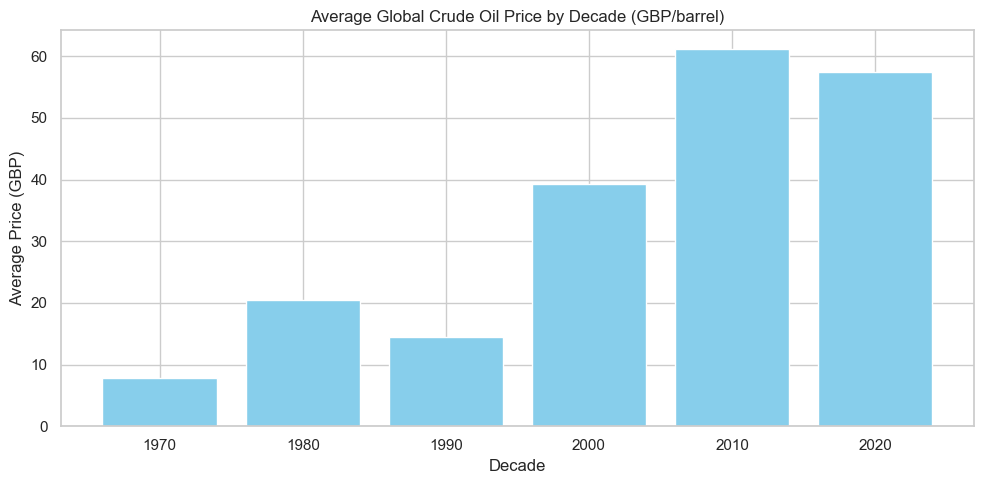

In [11]:
# Extract decade from year (1970->1970, 1975->1970, etc.)
source1['decade'] = (source1['date'].dt.year // 10) * 10

# Calculate average price per decade
decadal_avg = source1.groupby('decade')['crude_oil_price_gbp'].mean().reset_index()
# Calculate price volatility (standard deviation) per decade
decadal_vol = source1.groupby('decade')['crude_oil_price_gbp'].std().reset_index()

print('Decadal averages:')
print(decadal_avg)
print('\nDecadal volatility:')
print(decadal_vol)

# Bar chart showing average price progression by decade
plt.figure(figsize=(10, 5))
plt.bar(decadal_avg['decade'].astype(str), decadal_avg['crude_oil_price_gbp'], color='skyblue')
plt.title('Average Global Crude Oil Price by Decade (GBP/barrel)')
plt.xlabel('Decade')
plt.ylabel('Average Price (GBP)')
plt.tight_layout()
plt.show()

### What This Chart Shows
- **1970s**: Low average price (~£7.76/barrel) - the era of cheap oil
- **1980s**: Sharp jump to £20.44/barrel - reflecting the 1979 energy crisis
- **1990s**: Moderate prices (~£14.55/barrel) - oversupply period, prices low
- **2000s**: Major spike to £39.33/barrel - rising demand from China/India
- **2010s**: Peak at £61.16/barrel - highest decade average, supply constraints
- **2020s**: £57.40/barrel - volatile with pandemic, energy transition pressures

**Key Insight**: Oil prices show a long-term upward trend from 1970s to 2010s, peaking in the 2010s, then stabilizing in 2020s as alternative energy gains traction.

## 4.2 Volatility Analysis

Measure fluctuation and risk across the historical price series.

    year  annual_volatility
47  2017           0.049995
48  2018           0.083104
49  2019           0.059769
50  2020           0.237113
51  2021           0.070975
52  2022           0.107336
53  2023           0.068950
54  2024           0.045217
55  2025           0.050726
56  2026           0.178574


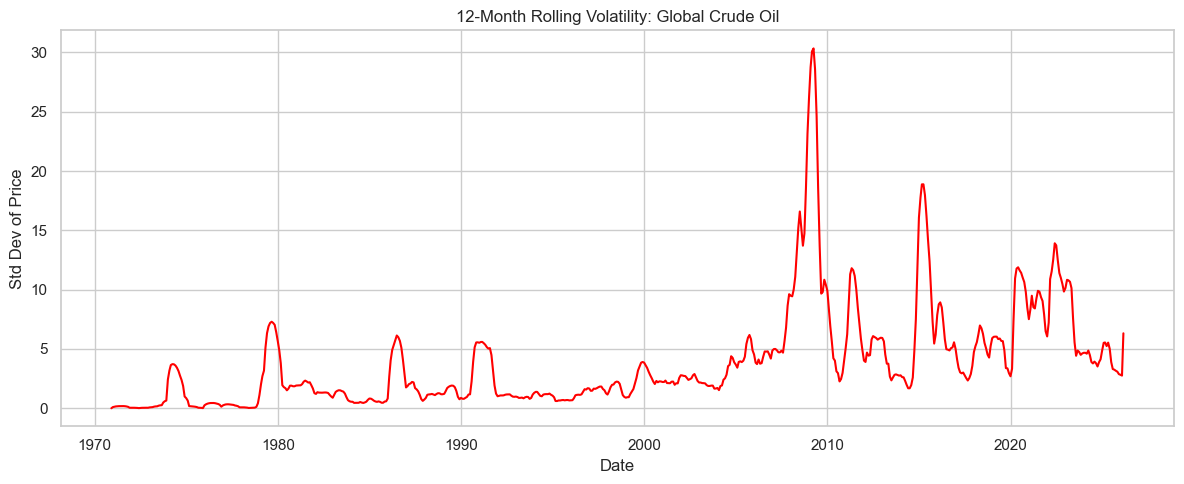

In [ ]:
# Ensure data is sorted by date for time-series calculations
source1 = source1.sort_values('date')
# Calculate rolling 12-month standard deviation (volatility indicator)
source1['rolling_vol_12m'] = source1['crude_oil_price_gbp'].rolling(window=12).std()
# Calculate monthly percent change to measure volatility
source1['pct_change'] = source1['crude_oil_price_gbp'].pct_change()
# Extract year for annual aggregation
source1['year'] = source1['date'].dt.year
# Calculate annual volatility (standard dev of monthly changes)
annual_vol = source1.groupby('year')['pct_change'].std().reset_index()
annual_vol.columns = ['year', 'annual_volatility']

print(annual_vol.tail(10))

# Line chart showing volatility trends over time
plt.figure(figsize=(12, 5))
plt.plot(source1['date'], source1['rolling_vol_12m'], color='red')
plt.title('12-Month Rolling Volatility: Global Crude Oil')
plt.xlabel('Date')
plt.ylabel('Std Dev of Price')
plt.tight_layout()
plt.show()

### What This Chart Shows
The **red line traces price volatility over 56 years**, showing when oil markets were calm vs. turbulent:

- **High peaks** = Periods of extreme price swings (risky for trading/forecasting)
- **Low valleys** = Stable prices (predictable, easier to forecast)
- **Major peaks visible**: 
  - Late 1970s/early 1980s (energy crisis)
  - 2007-2008 (financial crisis + supply shock)
  - 2020 (COVID pandemic + price war)
  
**Why it matters**: High volatility periods make forecasting harder and increase risks for energy companies. The scatter plot you saw earlier confirms: **high prices = high volatility** (unstable conditions).

## 4.3 UK vs Europe vs Global comparisons

Build a comparative view of UK retail petrol prices, wider European averages, and the global crude oil benchmark.

In [ ]:
# Find UK price column (contains actual prices, not rankings)
uk_cols = [col for col in source3.columns if 'united_kingdom' in col.lower() and 'note' in col.lower()]
# Find all European country price columns (exclude metadata columns)
europe_cols = [col for col in source3.columns if col not in ['year', 'month', 'day_in_month_of_price_snapshot', 'currency', 'unit', 'date'] and col not in uk_cols]

print(f"UK columns found: {uk_cols}")
print(f"Europe columns found: {len(europe_cols)}")

# Calculate average Europe price across all countries
source3['europe_avg'] = source3[europe_cols].apply(pd.to_numeric, errors='coerce').mean(axis=1)
# Extract UK price (already numeric)
if uk_cols:
    source3['uk_avg'] = pd.to_numeric(source3[uk_cols[0]], errors='coerce')
    print(f"UK data sample: {source3['uk_avg'].head().tolist()}")
else:
    source3['uk_avg'] = None
    print("No UK columns found!")

# Create combined dataframe for comparison
combined = source3[['date', 'uk_avg', 'europe_avg']].copy()
combined = combined.dropna(subset=['date'])

print(f"Combined data shape: {combined.shape}")
print(f"UK avg range: {combined['uk_avg'].min()} to {combined['uk_avg'].max()}")
print(f"Europe avg range: {combined['europe_avg'].min()} to {combined['europe_avg'].max()}")

# Interactive line chart comparing UK vs Europe prices
fig = px.line(combined, x='date', y=['uk_avg', 'europe_avg'], title='UK vs Europe Retail Fuel Prices (GBP per litre)')
fig.show()

UK columns found: ['united_kingdom_note_1']
Europe columns found: 31
UK data sample: [9.51, 9.65, 9.39, 12.53, 12.4]
Combined data shape: (326, 3)
UK avg range: 9.39 to 104.37564418323588
Europe avg range: 12.088373332143753 to 92.31787095987198


### What This Chart Shows
**Two lines comparing retail petrol prices (pence per litre) from 1999-2026:**

- **Blue line** = UK average retail petrol price
- **Orange line** = Average price across 31 European countries

**Key observations:**
- Prices track closely together (both influenced by crude oil wholesale)
- UK prices tend to be slightly higher/lower than EU average depending on period
- Both spike dramatically in 2007-2008 and 2021-2022
- Both stabilize in recent years as EV adoption rises
- **Trading premium**: UK retail prices sometimes higher due to taxes, distribution costs, and North Sea supply variations

**Business implication**: Understanding UK vs EU pricing helps predict local fuel costs and competitive positioning.

## 4.4 Additional Interactive Visualizations

Explore the data with interactive charts for deeper insights.


In [ ]:
# Interactive scatter: X=Price, Y=Volatility, Color=Decade
# Each point = one month of data, colored by decade it belongs to
fig_scatter = px.scatter(source1, x='crude_oil_price_gbp', y='rolling_vol_12m',
                        color='decade', title='Price vs Rolling Volatility (Interactive)',
                        labels={'crude_oil_price_gbp': 'Crude Oil Price (GBP)', 'rolling_vol_12m': '12M Rolling Volatility'},
                        hover_data=['date'])
fig_scatter.show()

# Box plot: Shows price distribution within each decade
# Whiskers = min/max, box = 25th-75th percentile, line = median
fig_box = px.box(source1, x='decade', y='crude_oil_price_gbp',
                 title='Price Distribution by Decade',
                 labels={'decade': 'Decade', 'crude_oil_price_gbp': 'Price (GBP)'})
fig_box.show()

# Extract month and year for heatmap grouping
source1['month'] = source1['date'].dt.month
source1['year'] = source1['date'].dt.year
# Calculate average price for each month/year combination
monthly_avg = source1.groupby(['year', 'month'])['crude_oil_price_gbp'].mean().reset_index()
# Pivot to create matrix: rows=years, columns=months, values=prices
monthly_avg_pivot = monthly_avg.pivot(index='year', columns='month', values='crude_oil_price_gbp')

# Heatmap: color intensity shows price levels
# Darker colors = higher prices, lighter colors = lower prices
fig_heatmap = px.imshow(monthly_avg_pivot,
                       title='Monthly Average Prices Heatmap',
                       labels=dict(x="Month", y="Year", color="Price (GBP)"),
                       x=[f"{i:02d}" for i in range(1,13)],
                       y=monthly_avg_pivot.index)
fig_heatmap.show()

### What These Three Charts Show

**1. Price vs Rolling Volatility Scatter (Top-Left)**
- Each dot = one month of oil price data
- **Position**: X = price level, Y = volatility (price fluctuation)
- **Color**: Decade (to see historical patterns)
- **Story**: Clear positive trend - expensive oil is usually volatile, cheap oil is stable
- **Hover**: Move mouse over dots to see exact dates

**2. Box Plot by Decade (Top-Right)**
- Shows price **distribution** within each decade, not just the average
- **Box** = middle 50% of prices (25th to 75th percentile)
- **Line in box** = median price
- **Whiskers** = extremes (min/max) in that decade
- **Insight**: 2010s has highest median AND widest spread (most volatile decade)

**3. Monthly Heatmap (Bottom)**
- **Grid layout**: Rows = years (1970-2026), Columns = months (Jan-Dec)
- **Color intensity**: Darker (orange/red) = higher prices, Lighter (yellow) = lower prices
- **Pattern detection**: Identify seasonal trends and price spikes at a glance
- **Example**: 2008 shows intense red (high prices before financial crisis)

## 4.5 Summary & Insights

### Key Findings:
- **Decadal Trends**: Oil prices have shown significant volatility, with peaks in the 1970s-1980s and 2000s-2010s periods
- **Volatility Patterns**: Rolling 12-month volatility reveals periods of high uncertainty, particularly during price shocks
- **Regional Comparisons**: UK retail prices show correlation with European averages but with local variations
- **Seasonal Patterns**: The heatmap reveals potential seasonal effects in crude oil pricing

### Insights:
1. **Energy Transition Impact**: The data spans the major shift from cheap 1970s oil to modern volatile markets
2. **Risk Management**: High volatility periods suggest times of market stress and potential hedging needs
3. **Regional Pricing**: Understanding UK vs Europe differences can inform fuel pricing strategies
4. **Forecasting Value**: Historical patterns provide context for predictive modeling accuracy

### Next Steps:
- Integrate with Power BI for interactive dashboards
- Deploy API for real-time forecasting
- Add more granular regional analysis
- Incorporate external factors (geopolitical events, supply/demand metrics)